In [6]:
import pandas as pd

# Load the Excel file to inspect the contents
file_path = '2023_naturaldisasters2.xlsx'
excel_data = pd.ExcelFile(file_path)

# Display the sheet names to understand the structure of the file
sheet_names = excel_data.sheet_names
sheet_names


['2023_naturaldisasters']

In [ ]:
# 'Prep_2lvls' is the column representing the preparedness levels.
# Count the number of occurrences of each preparedness level by 'natural_disaster'

preparedness_count = df.groupby(['natural_disaster', 'Prep_2lvls']).size().reset_index(name='count')

# Display the result to the user
import ace_tools as tools; tools.display_dataframe_to_user(name="Preparedness Level Counts by Natural Disaster", dataframe=preparedness_count)


In [ ]:
# Export the results to an Excel file
output_path = '/mnt/data/preparedness_count_by_disaster.xlsx'
preparedness_count.to_excel(output_path, index=False)

output_path


In [ ]:
# Re-import necessary libraries 
import pandas as pd

# Load the dataset
file_path = '2023_naturaldisasters2.xlsx'
excel_data = pd.ExcelFile(file_path)
df = excel_data.parse('2023_naturaldisasters')

# Generate a frequency count of preparedness levels
prep_freq = df['Prep_2lvls'].value_counts().reset_index()
prep_freq.columns = ['Prep_2lvls', 'Count']

prep_freq


,Prep_2lvls,Count
0,Unprepared,3880
1,Prepared,3724


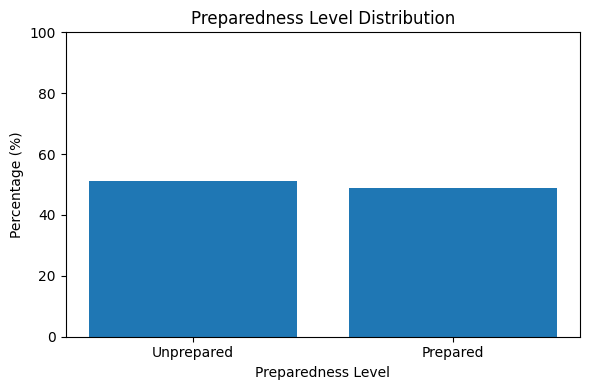

,Prep_2lvls,Percentage
0,Unprepared,51.03
1,Prepared,48.97


In [2]:
import matplotlib.pyplot as plt

# Calculate frequency as percentages
prep_percent = df['Prep_2lvls'].value_counts(normalize=True).reset_index()
prep_percent.columns = ['Prep_2lvls', 'Percentage']
prep_percent['Percentage'] = (prep_percent['Percentage'] * 100).round(2)

# Plot the percentages
plt.figure(figsize=(6, 4))
plt.bar(prep_percent['Prep_2lvls'], prep_percent['Percentage'])
plt.title('Preparedness Level Distribution')
plt.ylabel('Percentage (%)')
plt.xlabel('Preparedness Level')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

prep_percent


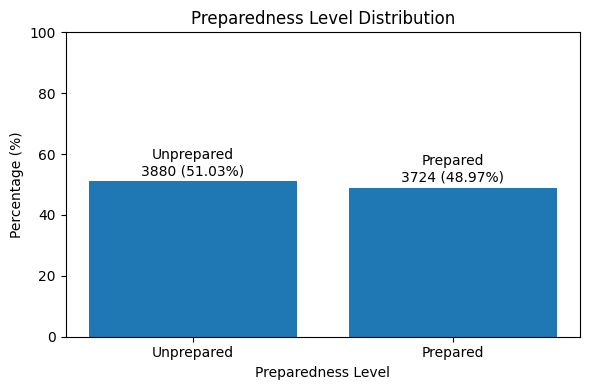

In [3]:
# Prepare labels with both count and percentage
labels = df['Prep_2lvls'].value_counts().index
counts = df['Prep_2lvls'].value_counts().values
percentages = (counts / counts.sum() * 100).round(2)
labels_with_info = [f"{label}\n{count} ({pct}%)" for label, count, pct in zip(labels, counts, percentages)]

# Plot the visual with counts and percentages
plt.figure(figsize=(6, 4))
bars = plt.bar(labels, percentages)
plt.title('Preparedness Level Distribution')
plt.ylabel('Percentage (%)')
plt.xlabel('Preparedness Level')
plt.ylim(0, 100)

# Annotate each bar with the count and percentage
for bar, label in zip(bars, labels_with_info):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, label, ha='center', va='bottom')

plt.tight_layout()
plt.show()


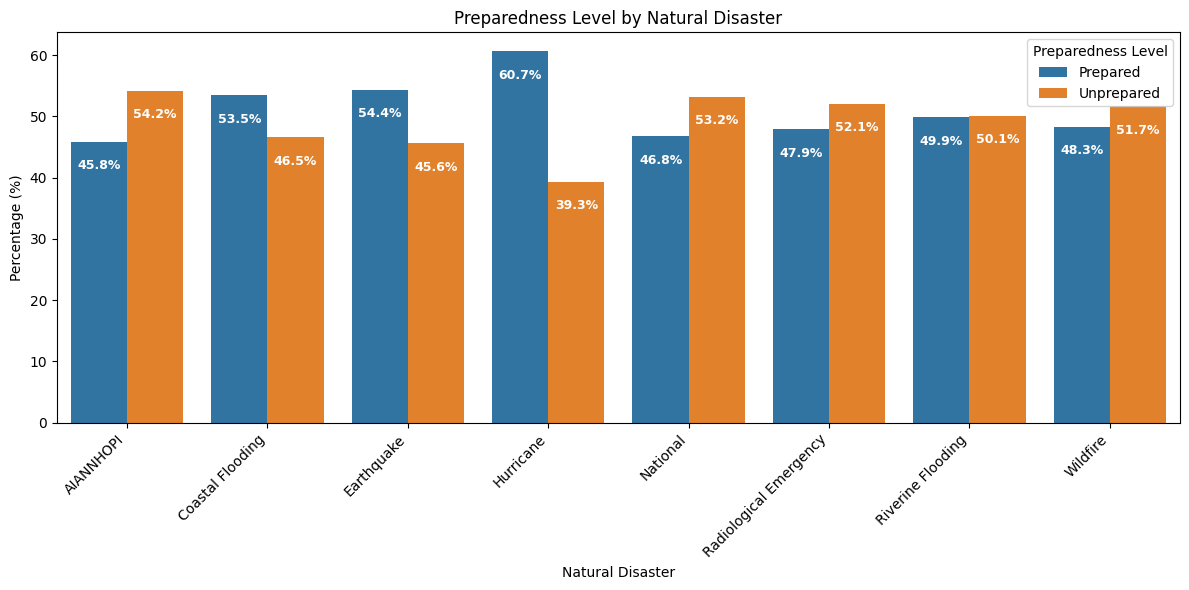

In [ ]:
# Re-import required libraries 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reload dataset
file_path = '2023_naturaldisasters2.xlsx'
excel_data = pd.ExcelFile(file_path)
df = excel_data.parse('2023_naturaldisasters')

# Group and calculate counts and percentages
prep_by_disaster = df.groupby(['natural_disaster', 'Prep_2lvls']).size().reset_index(name='count')
total_by_disaster = prep_by_disaster.groupby('natural_disaster')['count'].transform('sum')
prep_by_disaster['percentage'] = (prep_by_disaster['count'] / total_by_disaster * 100).round(2)

# Create bar chart with percentages labeled inside the bars
plt.figure(figsize=(12, 6))
barplot = sns.barplot(
    data=prep_by_disaster,
    x='natural_disaster',
    y='percentage',
    hue='Prep_2lvls'
)

# Add annotations inside each bar
for p in barplot.patches:
    height = p.get_height()
    if height > 0:
        barplot.annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2., height - 5),
            ha='center', va='bottom', color='white', fontsize=9, fontweight='bold'
        )

plt.title('Preparedness Level by Natural Disaster')
plt.xlabel('Natural Disaster')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Preparedness Level')
plt.tight_layout()
plt.show()




In [8]:
# Calculate preparedness level distribution by state
state_prep = df.groupby(['state', 'Prep_2lvls']).size().reset_index(name='count')

# Calculate percentages
total_by_state = state_prep.groupby('state')['count'].transform('sum')
state_prep['percentage'] = ((state_prep['count'] / total_by_state) * 100).round(0).astype(int)

# Pivot the data for table format
state_prep_table = state_prep.pivot(index='state', columns='Prep_2lvls', values='percentage').fillna(0).astype(int)

# Show the table
state_prep_table.head(10)  # showing top 10 rows for preview


Prep_2lvls,Prepared,Unprepared
state,,
Alabama,52,48
Alaska,53,47
American Samoa,33,67
Arizona,35,65
Arkansas,50,50
California,50,50
Colorado,41,59
Connecticut,54,46
Delaware,37,63


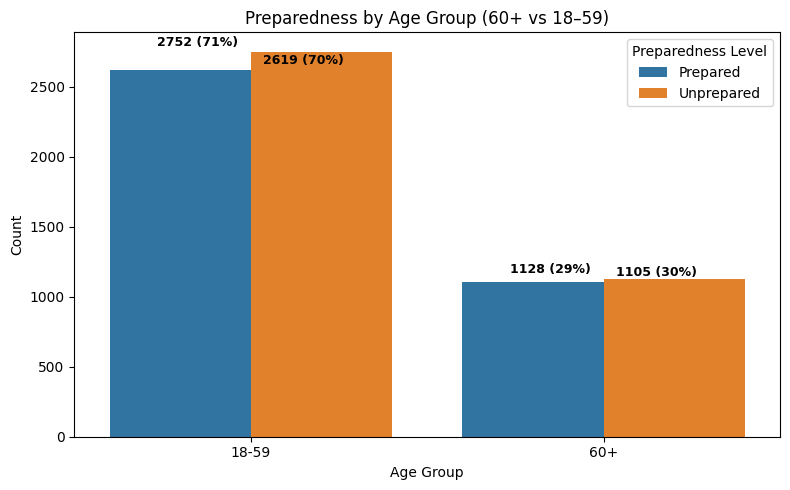

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the latest uploaded dataset
file_path = '2023_naturaldisasters2.xlsx'
excel_data = pd.ExcelFile(file_path)
df = excel_data.parse('2023_naturaldisasters')

# Calculate count and percentage of 'sixtyplus' by 'Prep_2lvls'
sixtyplus_prep = df.groupby(['sixtyplus', 'Prep_2lvls']).size().reset_index(name='count')
total_by_group = sixtyplus_prep.groupby('Prep_2lvls')['count'].transform('sum')
sixtyplus_prep['percentage'] = ((sixtyplus_prep['count'] / total_by_group) * 100).round(0).astype(int)

# Plot bar chart with counts and percentage inside the bars
plt.figure(figsize=(8, 5))
barplot = sns.barplot(data=sixtyplus_prep, x='sixtyplus', y='count', hue='Prep_2lvls')

# Annotate each bar with count and percentage
for i, row in sixtyplus_prep.iterrows():
    bar_index = i % 2  # ensure we place the text at the center of each bar pair
    plt.text(
        x=i // 2 + (0.15 if row['Prep_2lvls'] == 'Prepared' else -0.15),
        y=row['count'] + 20,
        s=f"{row['count']} ({row['percentage']}%)",
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

plt.title('Preparedness by Age Group (60+ vs 18–59)')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Preparedness Level')
plt.tight_layout()
plt.show()


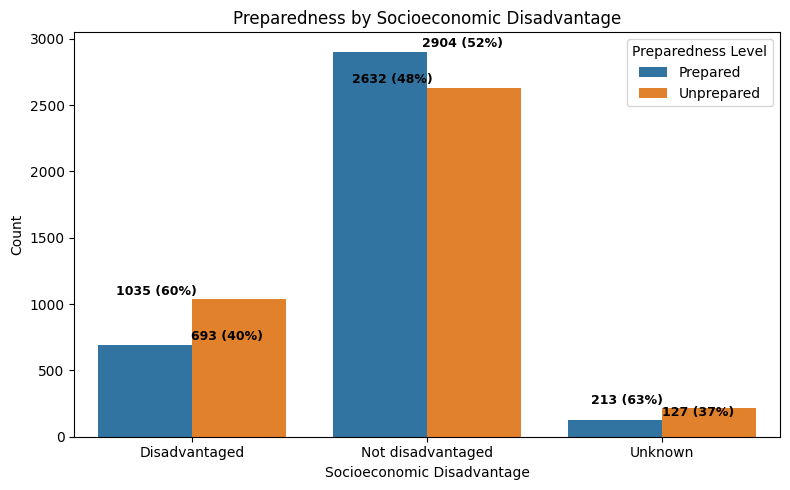

In [2]:
# Group by socioeconomic status and preparedness level
socio_prep = df.groupby(['socioeconomically_disadvantaged', 'Prep_2lvls']).size().reset_index(name='count')

# Calculate percentage within each socioeconomic group
total_by_socio = socio_prep.groupby('socioeconomically_disadvantaged')['count'].transform('sum')
socio_prep['percentage'] = ((socio_prep['count'] / total_by_socio) * 100).round(0).astype(int)

# Plot bar chart
plt.figure(figsize=(8, 5))
barplot = sns.barplot(data=socio_prep, x='socioeconomically_disadvantaged', y='count', hue='Prep_2lvls')

# Add annotations with count and percentage
for i, row in socio_prep.iterrows():
    x_offset = 0.15 if row['Prep_2lvls'] == 'Prepared' else -0.15
    plt.text(
        x=i // 2 + x_offset,
        y=row['count'] + 10,
        s=f"{row['count']} ({row['percentage']}%)",
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

plt.title('Preparedness by Socioeconomic Disadvantage')
plt.xlabel('Socioeconomic Disadvantage')
plt.ylabel('Count')
plt.legend(title='Preparedness Level')
plt.tight_layout()
plt.show()


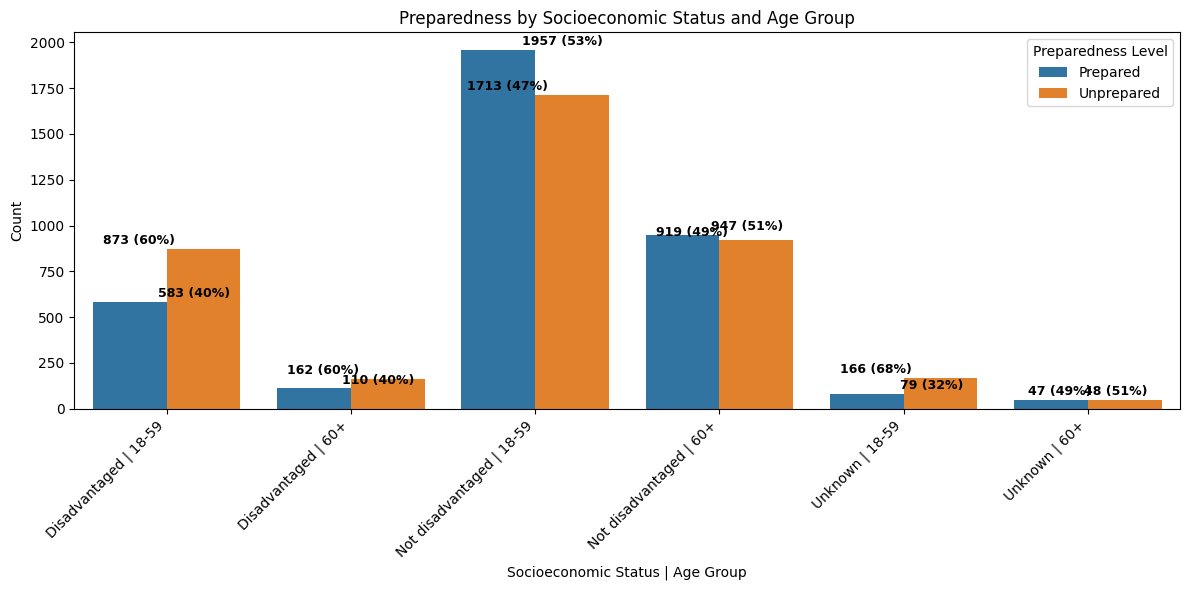

In [3]:
# Group by 'socioeconomically_disadvantaged', 'sixtyplus', and 'Prep_2lvls'
age_socio_group = df.groupby(['socioeconomically_disadvantaged', 'sixtyplus', 'Prep_2lvls']).size().reset_index(name='count')

# Calculate percentages within each combination of socioeconomic status and age group
total_by_age_socio = age_socio_group.groupby(['socioeconomically_disadvantaged', 'sixtyplus'])['count'].transform('sum')
age_socio_group['percentage'] = ((age_socio_group['count'] / total_by_age_socio) * 100).round(0).astype(int)

# Create combined label for x-axis
age_socio_group['Group'] = age_socio_group['socioeconomically_disadvantaged'] + ' | ' + age_socio_group['sixtyplus']

# Plot
plt.figure(figsize=(12, 6))
barplot = sns.barplot(data=age_socio_group, x='Group', y='count', hue='Prep_2lvls')

# Add annotations (count and percentage inside each bar)
for i, row in age_socio_group.iterrows():
    plt.text(
        x=i // 2 + (0.15 if row['Prep_2lvls'] == 'Prepared' else -0.15),
        y=row['count'] + 10,
        s=f"{row['count']} ({row['percentage']}%)",
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

plt.title('Preparedness by Socioeconomic Status and Age Group')
plt.xlabel('Socioeconomic Status | Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Preparedness Level')
plt.tight_layout()
plt.show()
